# Análisis de datos faltantes en acciones mexicanas

Objetivo:
1. Descargar precios históricos de múltiples acciones (.MX)
2. Analizar valores faltantes (NaN)
3. Identificar fechas problemáticas
4. Definir estrategia:
   - Relleno
   - Recorte temporal 

## Librerias

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import time 

## Descarga de Datos

In [2]:
tickers = [
"AC.MX","AGUILASCPO.MX","ALTERNA.MX","ASURB.MX","BBVA.MX","CADUA.MX","CMOCTEZ.MX","DIABLOSO.MX","FINDEP.MX","GBMO.MX","GFINBURO.MX","GISSAA.MX","GOMO.MX","HERDEZ.MX","ICA.MX","LAMOSA.MX","MEGACPO.MX","ORBIA.MX","POSADASA.MX","QBINDUSA.MX","SAREB.MX","SPORTS.MX","TRAXIONA.MX","VESTA.MX",

"ACCELSAB.MX","AHMSA.MX","AMXB.MX","AUTLANB.MX","BEVIDESB.MX","CEMEXCPO.MX","CMRB.MX","CTAXTELA.MX","DINEB.MX","FRAGUAB.MX","GCARSOA1.MX","GFMULTIO.MX","GMD.MX","GPH1.MX","HIMEXSAA.MX","ICHB.MX","KOFUBL.MX","LASEG.MX","MFRISCOA-1.MX","PASAB.MX","PLANI.MX","QUMMAB.MX","SAVIAA.MX","TEAKCPO.MX","TS.MX","VINTE.MX",

"ACTINVRB.MX","ANB.MX","AXTELCPO.MX","BIMBOA.MX","CHDRAUIB.MX","COLLADO.MX","CUERVO.MX","FRES.MX","GCC.MX","GFNORTEO.MX","GMEXICOB.MX","GPROFUT.MX","HOMEX.MX","IDEALB-1.MX","KUOB.MX","LASITE.MX","MINSAB.MX","PE&OLES.MX","PROCORPB.MX","RCENTROA.MX","SIMECB.MX","TEKCHEMA.MX","UNIFINA.MX","VISTAA.MX",

"AGRIEXPA.MX","ALPEKA.MX","ARA.MX","BOLSAA.MX","CIEB.MX","CONVERA.MX","CULTIBAB.MX","ELEKTRA.MX","GAPB.MX","GENTERA.MX","GICSAB.MX","GRUMAB.MX","HOTEL.MX","INVEXA.MX","LABB.MX","LIVEPOL1.MX","NEMAKA.MX","PINFRA.MX","PV.MX","RA.MX","SITES1A-1.MX","TLEVISACPO.MX","VALUEGFO.MX","VITROA.MX",

"AGUA.MX","ALSEA.MX","ARISTOSA.MX","BBAJIOO.MX","CABLECPO.MX","CIDMEGA.MX","CREAL.MX","CYDSASAA.MX","FINAMEXO.MX","GAVA.MX","GIGANTE.MX","GNP.MX","HCITY.MX","IASASA.MX","KIMBERA.MX","LACOMERUBC.MX","MEDICAB.MX","OMAB.MX","POCHTECB.MX","Q.MX","RLHA.MX","SORIANAB.MX","TMMA.MX","VASCONI.MX","VOLARA.MX"
]

In [3]:
start = "2020-01-01"
end = None

datos_por_ticker = {}

for ticker in tickers:
    try:
        print(f"Descargando {ticker}...")
        # Descarga individual
        df = yf.download(ticker, start=start, auto_adjust=True, progress=False)
        
        if not df.empty:
            datos_por_ticker[ticker] = df
        else:
            print(f" Advertencia: {ticker} no devolvió datos.")
            
        # Pequeña pausa para no saturar la API de Yahoo
        time.sleep(0.5) 
        
    except Exception as e:
        print(f"Error de conexión con {ticker}: {e}")

Descargando AC.MX...
Descargando AGUILASCPO.MX...
Descargando ALTERNA.MX...
Descargando ASURB.MX...
Descargando BBVA.MX...
Descargando CADUA.MX...
Descargando CMOCTEZ.MX...
Descargando DIABLOSO.MX...
Descargando FINDEP.MX...
Descargando GBMO.MX...
Descargando GFINBURO.MX...
Descargando GISSAA.MX...
Descargando GOMO.MX...
Descargando HERDEZ.MX...
Descargando ICA.MX...
Descargando LAMOSA.MX...
Descargando MEGACPO.MX...
Descargando ORBIA.MX...
Descargando POSADASA.MX...
Descargando QBINDUSA.MX...
Descargando SAREB.MX...
Descargando SPORTS.MX...
Descargando TRAXIONA.MX...
Descargando VESTA.MX...
Descargando ACCELSAB.MX...
Descargando AHMSA.MX...
Descargando AMXB.MX...
Descargando AUTLANB.MX...
Descargando BEVIDESB.MX...
Descargando CEMEXCPO.MX...
Descargando CMRB.MX...
Descargando CTAXTELA.MX...
Descargando DINEB.MX...
Descargando FRAGUAB.MX...
Descargando GCARSOA1.MX...
Descargando GFMULTIO.MX...
Descargando GMD.MX...
Descargando GPH1.MX...
Descargando HIMEXSAA.MX...
Descargando ICHB.MX..

In [4]:
prices = pd.concat(
    {ticker: datos_por_ticker[ticker]["Close"] for ticker in tickers},
    axis=1
)
prices.head()

,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
Ticker,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,77.489937,NaN,5.04542,273.006409,103.394844,6.920,38.725815,NaN,4.628801,9.022057,...,21.595087,9.244709,102.928589,5.95,62.165806,15.912635,23.509598,7.29,24.954983,20.020000
2020-01-03,78.181725,NaN,5.04780,274.346924,103.512566,7.100,38.725815,NaN,4.737714,9.022057,...,21.548567,9.249010,102.443848,5.95,62.025555,15.912635,23.755573,7.29,24.954983,20.190001
2020-01-06,77.889053,NaN,5.05114,269.337128,102.776688,7.115,38.725815,NaN,4.737714,9.022057,...,21.413654,8.894107,101.438133,5.90,62.859318,15.912635,23.391338,6.67,24.954983,19.795000
2020-01-07,78.622681,NaN,5.05159,272.309723,102.531395,7.100,38.725815,NaN,4.574345,9.022057,...,21.362482,8.894107,100.519249,5.95,63.256718,15.912635,23.651505,6.21,24.954983,20.059999
2020-01-08,78.364197,NaN,5.05225,275.051300,102.531395,7.110,38.326576,NaN,4.574345,9.022057,...,21.650911,9.249010,102.016960,5.95,62.048931,15.912635,23.462294,5.97,24.954983,20.250000


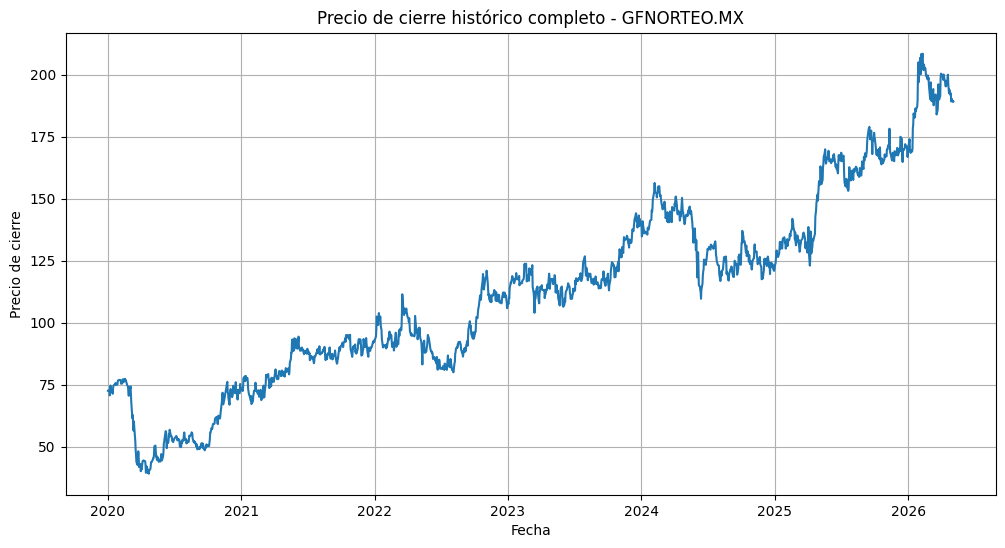

In [5]:
ticker = "GFNORTEO.MX"   
precio_completo = datos_por_ticker[ticker]["Close"].copy()
precio_completo = precio_completo.sort_index().dropna()

plt.figure(figsize=(12, 6))
plt.plot(precio_completo.index, precio_completo.values)

plt.title(f"Precio de cierre histórico completo - {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True)

plt.show()

In [6]:
prices.columns = prices.columns.get_level_values(0)
prices.head()

,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,77.489937,NaN,5.04542,273.006409,103.394844,6.920,38.725815,NaN,4.628801,9.022057,...,21.595087,9.244709,102.928589,5.95,62.165806,15.912635,23.509598,7.29,24.954983,20.020000
2020-01-03,78.181725,NaN,5.04780,274.346924,103.512566,7.100,38.725815,NaN,4.737714,9.022057,...,21.548567,9.249010,102.443848,5.95,62.025555,15.912635,23.755573,7.29,24.954983,20.190001
2020-01-06,77.889053,NaN,5.05114,269.337128,102.776688,7.115,38.725815,NaN,4.737714,9.022057,...,21.413654,8.894107,101.438133,5.90,62.859318,15.912635,23.391338,6.67,24.954983,19.795000
2020-01-07,78.622681,NaN,5.05159,272.309723,102.531395,7.100,38.725815,NaN,4.574345,9.022057,...,21.362482,8.894107,100.519249,5.95,63.256718,15.912635,23.651505,6.21,24.954983,20.059999
2020-01-08,78.364197,NaN,5.05225,275.051300,102.531395,7.110,38.326576,NaN,4.574345,9.022057,...,21.650911,9.249010,102.016960,5.95,62.048931,15.912635,23.462294,5.97,24.954983,20.250000


In [7]:
missing_count = prices.isna().sum().sort_values(ascending=False)
missing_count

DIABLOSO.MX      1361
AGUILASCPO.MX    1123
CTAXTELA.MX       857
LASITE.MX         701
SITES1A-1.MX      556
                 ... 
OMAB.MX             1
VASCONI.MX          1
SORIANAB.MX         1
VOLARA.MX           1
LACOMERUBC.MX       0
Length: 123, dtype: int64

In [8]:
missing_pct = (prices.isna().mean() * 100).sort_values(ascending=False)
missing_pct

DIABLOSO.MX      85.436284
AGUILASCPO.MX    70.495920
CTAXTELA.MX      53.797866
LASITE.MX        44.005022
SITES1A-1.MX     34.902699
                   ...    
OMAB.MX           0.062775
VASCONI.MX        0.062775
SORIANAB.MX       0.062775
VOLARA.MX         0.062775
LACOMERUBC.MX     0.000000
Length: 123, dtype: float64

In [9]:
missing_dates = prices[prices.isna().any(axis=1)]

missing_dates.head()

,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,77.489937,NaN,5.04542,273.006409,103.394844,6.920,38.725815,NaN,4.628801,9.022057,...,21.595087,9.244709,102.928589,5.95,62.165806,15.912635,23.509598,7.29,24.954983,20.020000
2020-01-03,78.181725,NaN,5.04780,274.346924,103.512566,7.100,38.725815,NaN,4.737714,9.022057,...,21.548567,9.249010,102.443848,5.95,62.025555,15.912635,23.755573,7.29,24.954983,20.190001
2020-01-06,77.889053,NaN,5.05114,269.337128,102.776688,7.115,38.725815,NaN,4.737714,9.022057,...,21.413654,8.894107,101.438133,5.90,62.859318,15.912635,23.391338,6.67,24.954983,19.795000
2020-01-07,78.622681,NaN,5.05159,272.309723,102.531395,7.100,38.725815,NaN,4.574345,9.022057,...,21.362482,8.894107,100.519249,5.95,63.256718,15.912635,23.651505,6.21,24.954983,20.059999
2020-01-08,78.364197,NaN,5.05225,275.051300,102.531395,7.110,38.326576,NaN,4.574345,9.022057,...,21.650911,9.249010,102.016960,5.95,62.048931,15.912635,23.462294,5.97,24.954983,20.250000


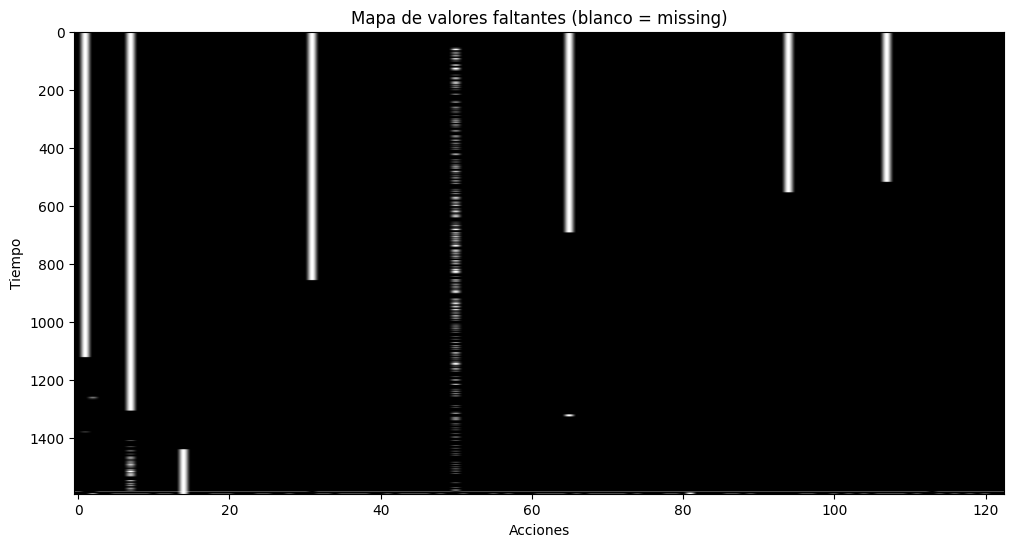

In [10]:
plt.figure(figsize=(12,6))
plt.imshow(prices.isna(), aspect='auto', cmap='gray')
plt.xlabel("Acciones")
plt.ylabel("Tiempo")
plt.title("Mapa de valores faltantes (blanco = missing)")
plt.show()

In [11]:
print("Total filas:", len(prices))
print("Filas completas:", prices.dropna().shape[0])

Total filas: 1593
Filas completas: 104


In [12]:
common_data = prices.dropna()

print("Periodo común:", common_data.index.min(), "->", common_data.index.max())

Periodo común: 2025-03-11 00:00:00 -> 2025-09-18 00:00:00


Tomemos ese rango :

In [13]:
periodo_inicio = "2025-03-11"
periodo_fin = "2026-04-5"

prices_common_window = prices.loc[periodo_inicio:periodo_fin].copy()

In [14]:
print("Filas totales en el rango:", len(prices_common_window))
print("Filas completas en el rango:", len(prices_common_window.dropna()))

Filas totales en el rango: 266
Filas completas en el rango: 104


In [15]:
fechas_con_nan = prices_common_window.index[prices_common_window.isna().any(axis=1)]
for fecha in fechas_con_nan[:10]:
    faltantes = prices_common_window.columns[prices_common_window.loc[fecha].isna()]
    print(f"{fecha.date()} -> {list(faltantes)}")

2025-03-19 -> ['ACTINVRB.MX']
2025-03-25 -> ['ACTINVRB.MX']
2025-03-26 -> ['ACTINVRB.MX']
2025-03-31 -> ['LASITE.MX']
2025-04-01 -> ['LASITE.MX']
2025-04-02 -> ['LASITE.MX']
2025-04-03 -> ['LASITE.MX']
2025-04-04 -> ['LASITE.MX']
2025-04-07 -> ['LASITE.MX']
2025-04-08 -> ['LASITE.MX']


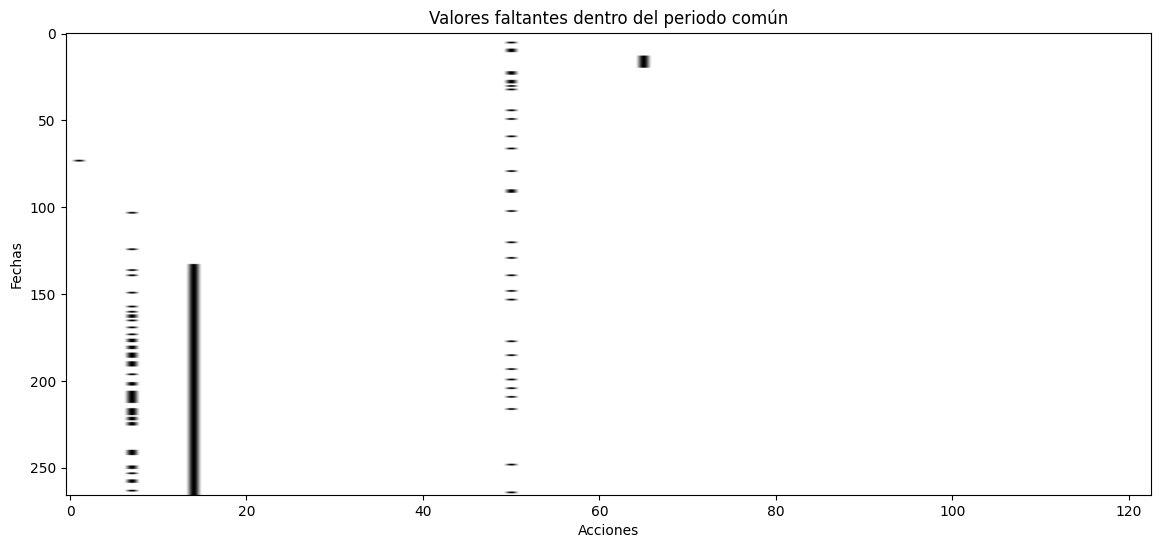

In [16]:
plt.figure(figsize=(14,6))
plt.imshow(prices_common_window.isna(), aspect='auto', cmap='gray_r')
plt.xlabel("Acciones")
plt.ylabel("Fechas")
plt.title("Valores faltantes dentro del periodo común")
plt.show()

## Tratamiento de los datos Faltantes 

In [17]:
df_work = prices_common_window.copy()
missing_pct = df_work.isna().mean()

# Columnas a eliminar
cols_drop = missing_pct[missing_pct > 0.10].index.tolist()

print("Columnas eliminadas (>10% faltantes):")
print(cols_drop)

df_work = df_work.drop(columns=cols_drop)

print("Shape después de eliminar columnas:", df_work.shape)

Columnas eliminadas (>10% faltantes):
['DIABLOSO.MX', 'ICA.MX', 'ACTINVRB.MX']
Shape después de eliminar columnas: (266, 120)


In [18]:
def find_nan_runs(series):
    """
    Regresa una lista de tuplas (start_idx, end_idx, run_length)
    para cada bloque consecutivo de NaN en una serie.
    """
    is_nan = series.isna().values
    runs = []
    n = len(series)
    i = 0
    
    while i < n:
        if is_nan[i]:
            start = i
            while i < n and is_nan[i]:
                i += 1
            end = i - 1
            runs.append((start, end, end - start + 1))
        else:
            i += 1
    
    return runs

### Caso 1

Rachas cortas (≤ 3 valores consecutivos)
Se imputan usando el promedio de los últimos 5 valores observados anteriores.

In [19]:
def fill_short(series, start, end, window=5):
    s = series.copy()

    for idx in range(start, end + 1):
        prev = s.iloc[max(0, idx-window):idx].dropna()
        if len(prev) > 0:
            s.iloc[idx] = prev.mean()

    return s

### Caso 2

Rachas largas (> 3 valores consecutivos)
Se utiliza interpolación lineal entre el último valor observado antes del bloque y el primer valor observado después del bloque.

Esto permite:
- Mantener continuidad temporal
- Evitar valores constantes artificiales
- Preservar tendencias

En caso de no existir un valor anterior o posterior, los valores se dejan como NaN.

In [20]:
def fill_long_linear(series, start, end):
    s = series.copy()

    prev_idx = start - 1
    next_idx = end + 1

    if prev_idx >= 0 and next_idx < len(s):
        prev_val = s.iloc[prev_idx]
        next_val = s.iloc[next_idx]

        if pd.notna(prev_val) and pd.notna(next_val):
            run_len = end - start + 1

            for k, idx in enumerate(range(start, end + 1), start=1):
                s.iloc[idx] = prev_val + (next_val - prev_val) * (k / (run_len + 1))

    return s

### Aplicacion de Estrategias

In [21]:
def impute_series(series):
    s = series.copy()
    runs = find_nan_runs(s)

    for start, end, length in runs:
        if length <= 3:
            s = fill_short(s, start, end)
        else:
            s = fill_long_linear(s, start, end)

    return s

In [22]:
df_imputed = df_work.copy()

for col in df_imputed.columns:
    df_imputed[col] = impute_series(df_imputed[col])

In [23]:
print("NaN antes:", df_work.isna().sum().sum())
print("NaN después:", df_imputed.isna().sum().sum())

NaN antes: 8
NaN después: 0


In [24]:
mask_original = df_work.isna()
mask_imputed = mask_original & df_imputed.notna()

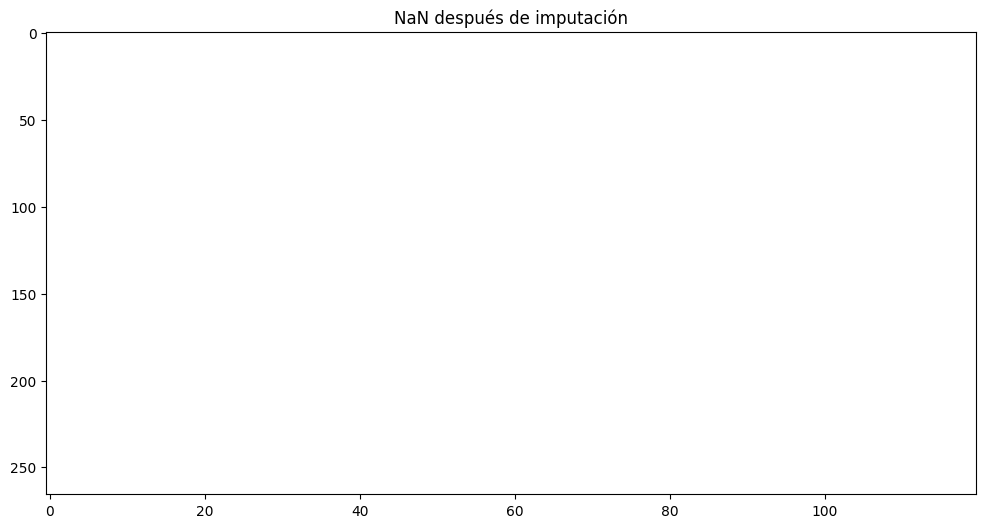

In [25]:
plt.figure(figsize=(12,6))
plt.imshow(df_imputed.isna(), aspect='auto', cmap='gray_r')
plt.title("NaN después de imputación")
plt.show()

In [26]:
# Pasar a un csv 
df_imputed.to_csv("./datoslimpos.csv")

# Construcción de Features Financieras

In [27]:
prices = df_imputed.copy()
prices = prices.sort_index()
prices.columns.name = None

1. Retornos (Returns)

**Definición:**
El retorno mide el cambio porcentual en el precio de un activo.

$$
r_t = \frac{P_t}{P_{t-1}} - 1
$$

**Tipos usados:**

- **ret_1d**: retorno diario
- **ret_5d**: retorno acumulado en 5 días
- **ret_20d**: retorno acumulado en 20 días

**Intuición:**
- Captura momentum de corto, mediano y largo plazo
- Base de prácticamente todos los modelos financieros

2. Volatilidad

**Definición:**
Desviación estándar de los retornos en una ventana móvil.

$$
\sigma_t = \sqrt{\frac{1}{n} \sum (r_t - \bar{r})^2}
$$

**Variables:**

- **vol_5d**
- **vol_20d**

**Intuición:**
- Mide riesgo
- Alta volatilidad = mayor incertidumbre

3. Medias Móviles (Moving Averages)

**Definición:**
Promedio del precio en una ventana de tiempo.

$$
MA_t = \frac{1}{n} \sum_{i=0}^{n} P_{t-i}
$$

**Variables:**

- **ma_5**
- **ma_20**
- **ma_60**

**Intuición:**
- Identifican tendencia
- Suavizan ruido del precio

4. Distancia a la Media Móvil

**Definición:**

$$
dist\_ma = \frac{P_t - MA_t}{MA_t}
$$

**Variables:**

- **dist_ma_5**
- **dist_ma_20**
- **dist_ma_60**

**Intuición:**
- Indica sobrecompra o sobreventa
- Si es positivo → precio arriba de tendencia
- Si es negativo → precio debajo

5. RSI (Relative Strength Index)

**Definición:**
Oscilador que mide la fuerza del movimiento de precios.

$$
RSI = 100 - \frac{100}{1 + RS}
$$

donde:

$$
RS = \frac{\text{promedio de ganancias}}{\text{promedio de pérdidas}}
$$

**Variable:**

- **rsi_14**

**Intuición:**
- >70 → sobrecompra
- <30 → sobreventa

In [28]:
ticker = "GFNORTEO.MX"  

price_series = prices[[ticker]].copy()

ret_1d = price_series.pct_change(fill_method=None).rename(columns={ticker: "ret_1d"})
ret_5d = price_series.pct_change(5, fill_method=None).rename(columns={ticker: "ret_5d"})
ret_20d = price_series.pct_change(20, fill_method=None).rename(columns={ticker: "ret_20d"})

vol_5d = ret_1d.rolling(5).std().rename(columns={"ret_1d": "vol_5d"})
vol_20d = ret_1d.rolling(20).std().rename(columns={"ret_1d": "vol_20d"})

ma_5 = price_series.rolling(5).mean().rename(columns={ticker: "ma_5"})
ma_20 = price_series.rolling(20).mean().rename(columns={ticker: "ma_20"})
ma_60 = price_series.rolling(60).mean().rename(columns={ticker: "ma_60"})

dist_ma_5 = ((price_series[ticker] - ma_5["ma_5"]) / ma_5["ma_5"]).to_frame("dist_ma_5")
dist_ma_20 = ((price_series[ticker] - ma_20["ma_20"]) / ma_20["ma_20"]).to_frame("dist_ma_20")
dist_ma_60 = ((price_series[ticker] - ma_60["ma_60"]) / ma_60["ma_60"]).to_frame("dist_ma_60")

delta = price_series.diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
rsi_14 = (100 - (100 / (1 + rs))).rename(columns={ticker: "rsi_14"})

In [29]:
features_ticker = pd.concat([
    price_series.rename(columns={ticker: "close"}),
    ret_1d,
    ret_5d,
    ret_20d,
    vol_5d,
    vol_20d,
    ma_5,
    ma_20,
    ma_60,
    dist_ma_5,
    dist_ma_20,
    dist_ma_60,
    rsi_14
], axis=1)

features_ticker = features_ticker.dropna().copy()

features_ticker.head()

,close,ret_1d,ret_5d,ret_20d,vol_5d,vol_20d,ma_5,ma_20,ma_60,dist_ma_5,dist_ma_20,dist_ma_60,rsi_14
Date,,,,,,,,,,,,,
2025-06-06,164.812515,0.000699,-0.001977,0.056687,0.005319,0.013431,164.975714,165.592517,147.660130,-0.000989,-0.004710,0.116161,36.641570
2025-06-09,166.386917,0.009553,0.007674,0.055413,0.006949,0.013396,165.229153,166.029316,148.280987,0.007007,0.002154,0.122106,52.369827
2025-06-10,167.577316,0.007154,0.010127,0.030400,0.007304,0.011626,165.565155,166.276515,148.881651,0.012153,0.007823,0.125574,60.618671
2025-06-11,165.359726,-0.013233,0.006133,0.007781,0.008868,0.011939,165.766757,166.340356,149.443248,-0.002455,-0.005895,0.106505,52.424120
2025-06-12,167.999710,0.015965,0.020051,0.005632,0.011089,0.011779,166.427237,166.387395,150.024314,0.009448,0.009690,0.119817,53.897756


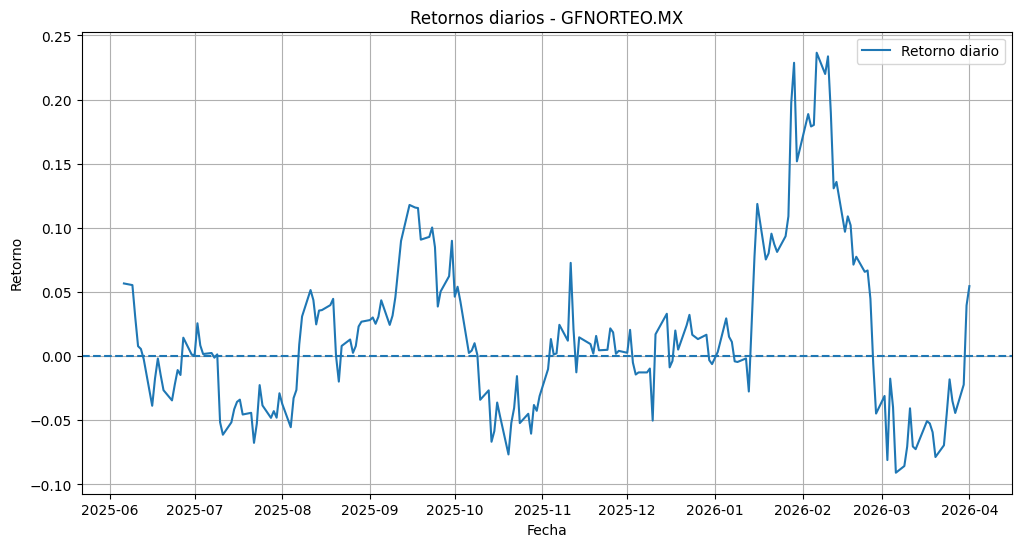

In [30]:
plt.figure(figsize=(12,6))

plt.plot(features_ticker.index, features_ticker["ret_20d"], label="Retorno diario")

plt.axhline(0, linestyle="--")  
plt.title(f"Retornos diarios - {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.legend()
plt.grid(True)

plt.show()

# División Train/Test para series de tiempo

En series de tiempo no se puede dividir de forma aleatoria debido a dependencia temporal.

Además, cuando se utilizan features con ventanas móviles (ej. retornos a 5 días), es necesario dejar un "gap" entre train y test para evitar fuga de información (data leakage).

Este gap debe ser al menos igual a la ventana máxima utilizada en las features.

In [31]:
df = features_ticker.copy()

# Target (ejemplo)
y = df["ret_1d"].shift(-1)

# Features
X = df.drop(columns=["ret_1d"])

# Alinear
X = X.iloc[:-1]
y = y.iloc[:-1] 

split_ratio = 0.7
desired_gap = 3

n = len(X)
split_idx = int(n * split_ratio)

max_possible_gap = max(0, n - split_idx - 1)
gap = min(desired_gap, max_possible_gap)

train_end = split_idx
test_start = split_idx + gap

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_test = X.iloc[test_start:]
y_test = y.iloc[test_start:]

print("n total:", n)
print("Gap usado:", gap)
print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Train:", X_train.index.min(), "->", X_train.index.max())
print("Test :", X_test.index.min(), "->", X_test.index.max())

n total: 206
Gap usado: 3
Train size: 144
Test size: 59
Train: 2025-06-06 00:00:00 -> 2025-12-30 00:00:00
Test : 2026-01-06 00:00:00 -> 2026-03-31 00:00:00
